# 4-3 과제 | 건포도 품종 분류기 만들기

건포도 900개의 크기·모양 측정값이 있음. 두 품종(**Kecimen** / **Besni**)을 구분하는 모델을 만드셈.

---

## 문제 6개

| # | 문제 |
|---|---|
| **1** | 측정값 7개 중 **2개를 골라** 근거를 적으셈 |
| **2** | 그 2개로 **로지스틱 회귀**와 **KNN(k=5)** 을 만들고 validation 정확도를 비교하셈 |
| **3** | KNN 을 **스케일링해서 다시** 재고, 무엇이 달라졌는지 적으셈 |
| **4** | KNN 의 **k 를 train 내부 CV로** 고르셈 |
| **5** | 최종 모델 **하나**를 고르고 근거를 적으셈 |
| **6** | **그 다음에** test 를 **딱 한 번** 평가하셈 |

---

## 지켜야 할 것

> **문제 6 전에는 test 를 열지 마셈.**
> **test 점수를 보고 모델을 바꾸지 마셈.**

3-2 · 4-1 · 4-2 에서 계속 한 얘기임.
**고르는 데 쓴 점수는 성능이 아님.** 고를 때는 validation, test 는 마지막 한 번.

---

## 참고

- 데이터는 이미 **train 576 / validation 144 / test 180** 으로 나눠져 있음
- **할 일은 각 코드 셀 안에 주석으로** 적어놨음
- 4-1 · 4-2 노트북을 열어놓고 **보고 베껴 써도 됨.** 그게 정상적인 학습임
- 막히면 문제 아래 **힌트를 펼치셈**
- **정답이 하나로 정해져 있지 않음.** 사람마다 다른 답이 나오는 게 정상임
- 변수 이름도 **직접 정하셈.** 결과를 확인하는 `print` 도 직접 쓰셈

*데이터: UCI Machine Learning Repository — Raisin (id 850), CC BY 4.0*

In [ ]:
#%pip install ucimlrepo

  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
Using cached certifi-2026.7.22-py3-none-any.whl (136 kB)

   -------------------- ------------------- 1/2 [ucimlrepo]
   ---------------------------------------- 2/2 [ucimlrepo]

Note: you may need to restart the kernel to use updated packages.


## 준비 — 실행만 하고 넘어가셈

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 데이터: UCI Machine Learning Repository — Raisin (id=850), CC BY 4.0
try:
    from ucimlrepo import fetch_ucirepo
    df = fetch_ucirepo(id=850).data.original
    print("데이터: UCI 에서 직접 받음")
except Exception as e:
    df = pd.read_csv("raisin.csv")          # 인터넷이 안 되면 옆에 둔 파일
    print("데이터: raisin.csv 에서 읽음 -", type(e).__name__)

# train 576 / validation 144 / test 180
dev, test_df = train_test_split(df, test_size=0.2, stratify=df["Class"], random_state=42)
train_df, valid_df = train_test_split(dev, test_size=0.2, stratify=dev["Class"], random_state=42)
y_train, y_valid, y_test = train_df["Class"], valid_df["Class"], test_df["Class"]

FEATURES = [c for c in df.columns if c != "Class"]


def plot_pair(f1, f2):
    """train 576행으로 두 측정값 산점도를 그림 — 쓰고 싶으면 쓰셈"""
    for label, g in train_df.groupby("Class"):
        plt.scatter(g[f1], g[f2], s=20, alpha=.55, label=label)
        
    plt.xlabel(f1); plt.ylabel(f2); plt.legend(); plt.grid(alpha=.15)
    plt.title(f"{f1} vs {f2}  (train)")
    plt.show()


print("train", len(train_df), "/ validation", len(valid_df), "/ test", len(test_df))
print("class", dict(df["Class"].value_counts()))
print("features", FEATURES)
print("baseline(찍기)", 0.5)
display(train_df.head())
display(train_df['Class'].value_counts())



데이터: UCI 에서 직접 받음
train 576 / validation 144 / test 180
class {'Kecimen': np.int64(450), 'Besni': np.int64(450)}
features ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
baseline(찍기) 0.5


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
475,177264,619.958472,366.763240,0.806237,180994,0.683219,1652.694,Besni
39,49882,287.264327,222.185873,0.633852,50880,0.766378,843.764,Kecimen
192,37569,232.427848,208.152006,0.444950,38874,0.794371,734.102,Kecimen
585,61444,371.693826,213.179806,0.819180,64321,0.737473,1006.984,Besni
535,77012,425.219427,239.469561,0.826343,81325,0.654280,1131.530,Besni


Class
Besni      288
Kecimen    288
Name: count, dtype: int64

In [24]:
df_numeric[FEATURES]

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
475,177264,619.958472,366.763240,0.806237,180994,0.683219,1652.694
39,49882,287.264327,222.185873,0.633852,50880,0.766378,843.764
192,37569,232.427848,208.152006,0.444950,38874,0.794371,734.102
585,61444,371.693826,213.179806,0.819180,64321,0.737473,1006.984
535,77012,425.219427,239.469561,0.826343,81325,0.654280,1131.530
...,...,...,...,...,...,...,...
298,105020,440.389631,306.105289,0.718934,107423,0.714616,1228.366
517,97375,468.904038,268.267025,0.820173,100169,0.694717,1244.252
834,145235,609.630181,306.608036,0.864321,148876,0.682495,1538.316
456,134303,600.766271,288.384930,0.877253,138133,0.742436,1497.515


In [23]:
df_numeric[FEATURES].apply(pd.to_numeric)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
475,177264,619.958472,366.763240,0.806237,180994,0.683219,1652.694
39,49882,287.264327,222.185873,0.633852,50880,0.766378,843.764
192,37569,232.427848,208.152006,0.444950,38874,0.794371,734.102
585,61444,371.693826,213.179806,0.819180,64321,0.737473,1006.984
535,77012,425.219427,239.469561,0.826343,81325,0.654280,1131.530
...,...,...,...,...,...,...,...
298,105020,440.389631,306.105289,0.718934,107423,0.714616,1228.366
517,97375,468.904038,268.267025,0.820173,100169,0.694717,1244.252
834,145235,609.630181,306.608036,0.864321,148876,0.682495,1538.316
456,134303,600.766271,288.384930,0.877253,138133,0.742436,1497.515


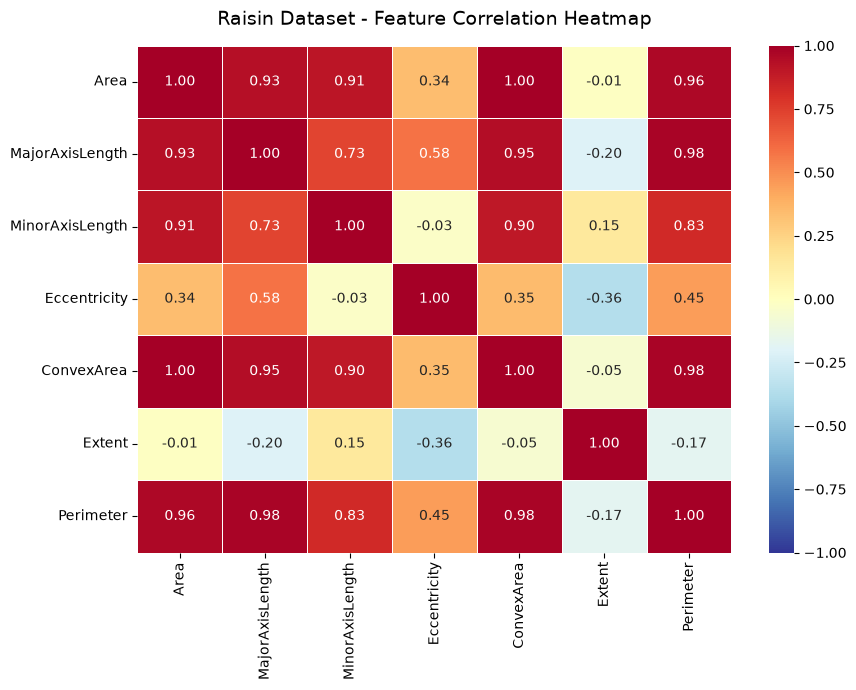

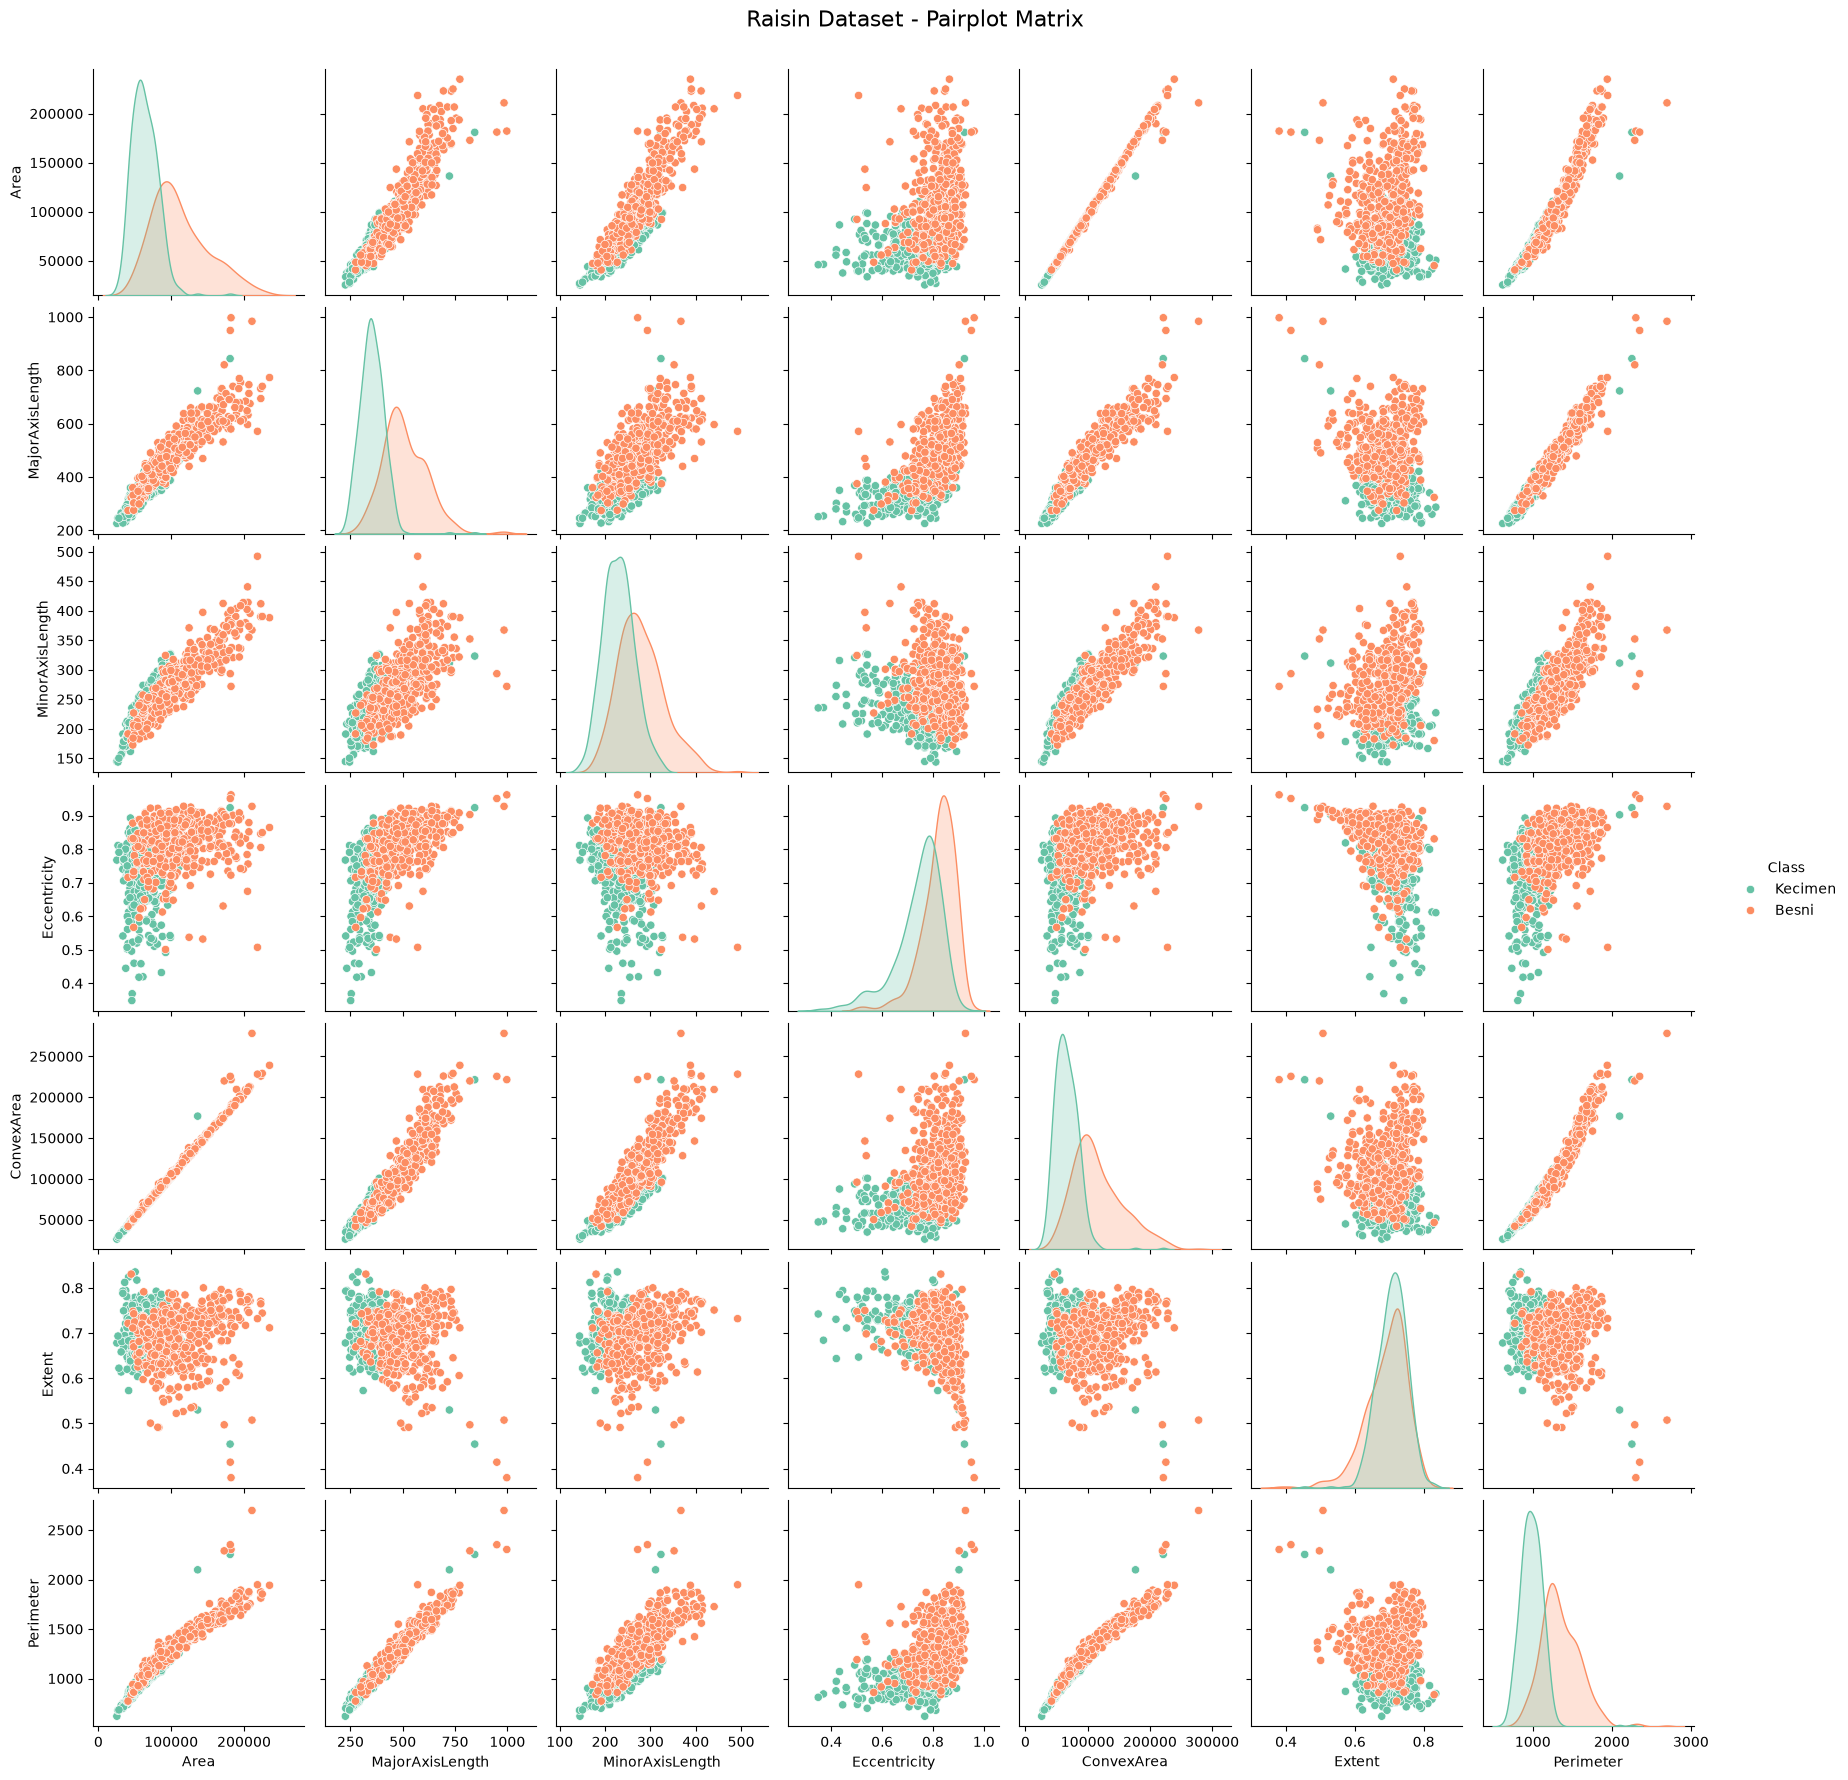

In [84]:
#변수 간 관계를 완벽하게 시각화
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# 1. 데이터셋 로드 (ID 850: Raisin)
raisin = fetch_ucirepo(id=850)
df = raisin.data.original

# 분석할 주요 특징(features) 선택
features = [
    "Area",
    "MajorAxisLength",
    "MinorAxisLength",
    "Eccentricity",
    "ConvexArea",
    "Extent",
    "Perimeter",
]
df_features = df[features]

# 2. 피어슨 상관계수 행렬 계산
corr_matrix = df_features.corr(method="pearson")

# 3. 상관관계 히트맵 시각화
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Raisin Dataset - Feature Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 4. 산점도 행렬(Pairplot) 시각화 (품종별 분포 경향 포함)
# 클래스(품종) 정보가 있다면 hue에 지정하여 품종별 차이도 함께 볼 수 있습니다.
sns.pairplot(df, vars=features, hue="Class", palette="Set2", diag_kind="kde")
plt.suptitle("Raisin Dataset - Pairplot Matrix", y=1.02, fontsize=16)
plt.show()

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

def analyze_features_for_selection(df, feature_cols, target_col):
    """
    임의의 데이터셋에 대해 타겟 상관관계와 다중공선성(VIF)을 분석하여 변수 선택 리포트를 생성합니다.
    피처 데이터 내에 문자열이 오염되어 섞여 있어도 완전히 강제 숫자로 정제하여 계산합니다.
    """
    print(f"\n[알림] 총 {len(feature_cols)}개의 변수와 타겟 '{target_col}'에 대한 분석을 시작합니다.")
    
    # 1. 안전하게 독립변수(X) 추출 및 데이터 타입 강제 정제
    X = pd.DataFrame()
    for col in feature_cols:
        # errors='coerce'를 사용하면 'Kecimen' 같은 잘못 섞인 문자열은 모두 NaN(결측치)으로 바뀝니다.
        X[col] = pd.to_numeric(df[col], errors='coerce')
        
    y = df[target_col].copy()
    
    # 2. 강제 변환 후 발생한 결측치 처리 (중간값으로 대체하여 연산 에러 방지)
    if X.isnull().sum().sum() > 0:
        print("[주의] 수치형 변수 내에 문자열 오염 또는 결측치가 발견되어 자동으로 수치 정제 및 대체 처리를 수행했습니다.")
        X = X.fillna(X.median())
        
    # 3. 타겟 변수 인코딩 처리 (문자형 데이터 'Kecimen', 'Besni' 등을 0, 1로 변환)
    if y.dtype == 'str' or y.dtype == 'object' or y.dtype.name == 'category':
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        print(f"[정보] 타겟 변수 '{target_col}'가 문자형이므로 라벨 인코딩을 적용했습니다. (클래스: {le.classes_})")
    else:
        y_encoded = y.values

    # 4. 타겟(Y)과의 상관관계 계산 (정제된 X 데이터와 1:1 매칭 확인)
    y_series = pd.Series(y_encoded, index=X.index)
    target_corr = X.corrwith(y_series).abs()

    # 5. 다중공선성(VIF) 계산
    X_vif = X.copy()
    X_vif['intercept'] = 1.0

    vif_values = []
    for i in range(len(feature_cols)):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
            vif_values.append(vif)
        except Exception as e:
            vif_values.append(np.nan)
            print(f"[오류] {feature_cols[i]} 변수의 VIF 계산 실패: {e}")

    # 6. 실무용 통합 의사결정 리포트 생성
    report_df = pd.DataFrame({
        'Target_Correlation_Abs': target_corr,
        'VIF_Score': vif_values
    })

    # 타겟 기여도가 높은 순서 정렬
    report_df = report_df.sort_values(by='Target_Correlation_Abs', ascending=False)

    print("\n" + "="*60)
    print("       [실무 의사결정용 변수 분석 통합 리포트]       ")
    print("="*60)
    print(report_df.round(4))
    print("="*60)
    print("* 가이드라인: Target_Correlation은 높을수록 핵심 변수이며,")
    print("              VIF_Score가 10 이상이면 중복 변수이므로 제외를 검토하세요.\n")

    # 7. 분포 시각화
    print("[알림] 변수별 품종 분리도 시각화를 출력합니다...")
    num_features = len(feature_cols)
    cols_per_row = 4
    rows = (num_features + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 5 * rows))
    if rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        # 시각화 데이터는 원본 df를 사용하되 타겟별 정상 분리 형태 유지
        # 수정 전 Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 
        #sns.boxplot(data=df, x=target_col, y=pd.to_numeric(df[col], errors='coerce'), ax=axes[i], palette='Set2')
        # 수정 후
        sns.boxplot(data=df, x=target_col, y=pd.to_numeric(df[col], errors='coerce'), ax=axes[i], hue=target_col, palette='Set2', legend=False)

        axes[i].set_title(f'{col} by {target_col}')
        axes[i].set_xlabel('')

    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    
    return report_df



[알림] 총 7개의 변수와 타겟 'Class'에 대한 분석을 시작합니다.
[정보] 타겟 변수 'Class'가 문자형이므로 라벨 인코딩을 적용했습니다. (클래스: ['Besni' 'Kecimen'])

       [실무 의사결정용 변수 분석 통합 리포트]       
                 Target_Correlation_Abs  VIF_Score
MajorAxisLength                  0.6732   129.1529
Perimeter                        0.6660   184.2528
Area                             0.6257   404.7188
ConvexArea                       0.6256   445.9476
MinorAxisLength                  0.5031    40.1666
Eccentricity                     0.4385     5.2104
Extent                           0.1547     1.6053
* 가이드라인: Target_Correlation은 높을수록 핵심 변수이며,
              VIF_Score가 10 이상이면 중복 변수이므로 제외를 검토하세요.

[알림] 변수별 품종 분리도 시각화를 출력합니다...


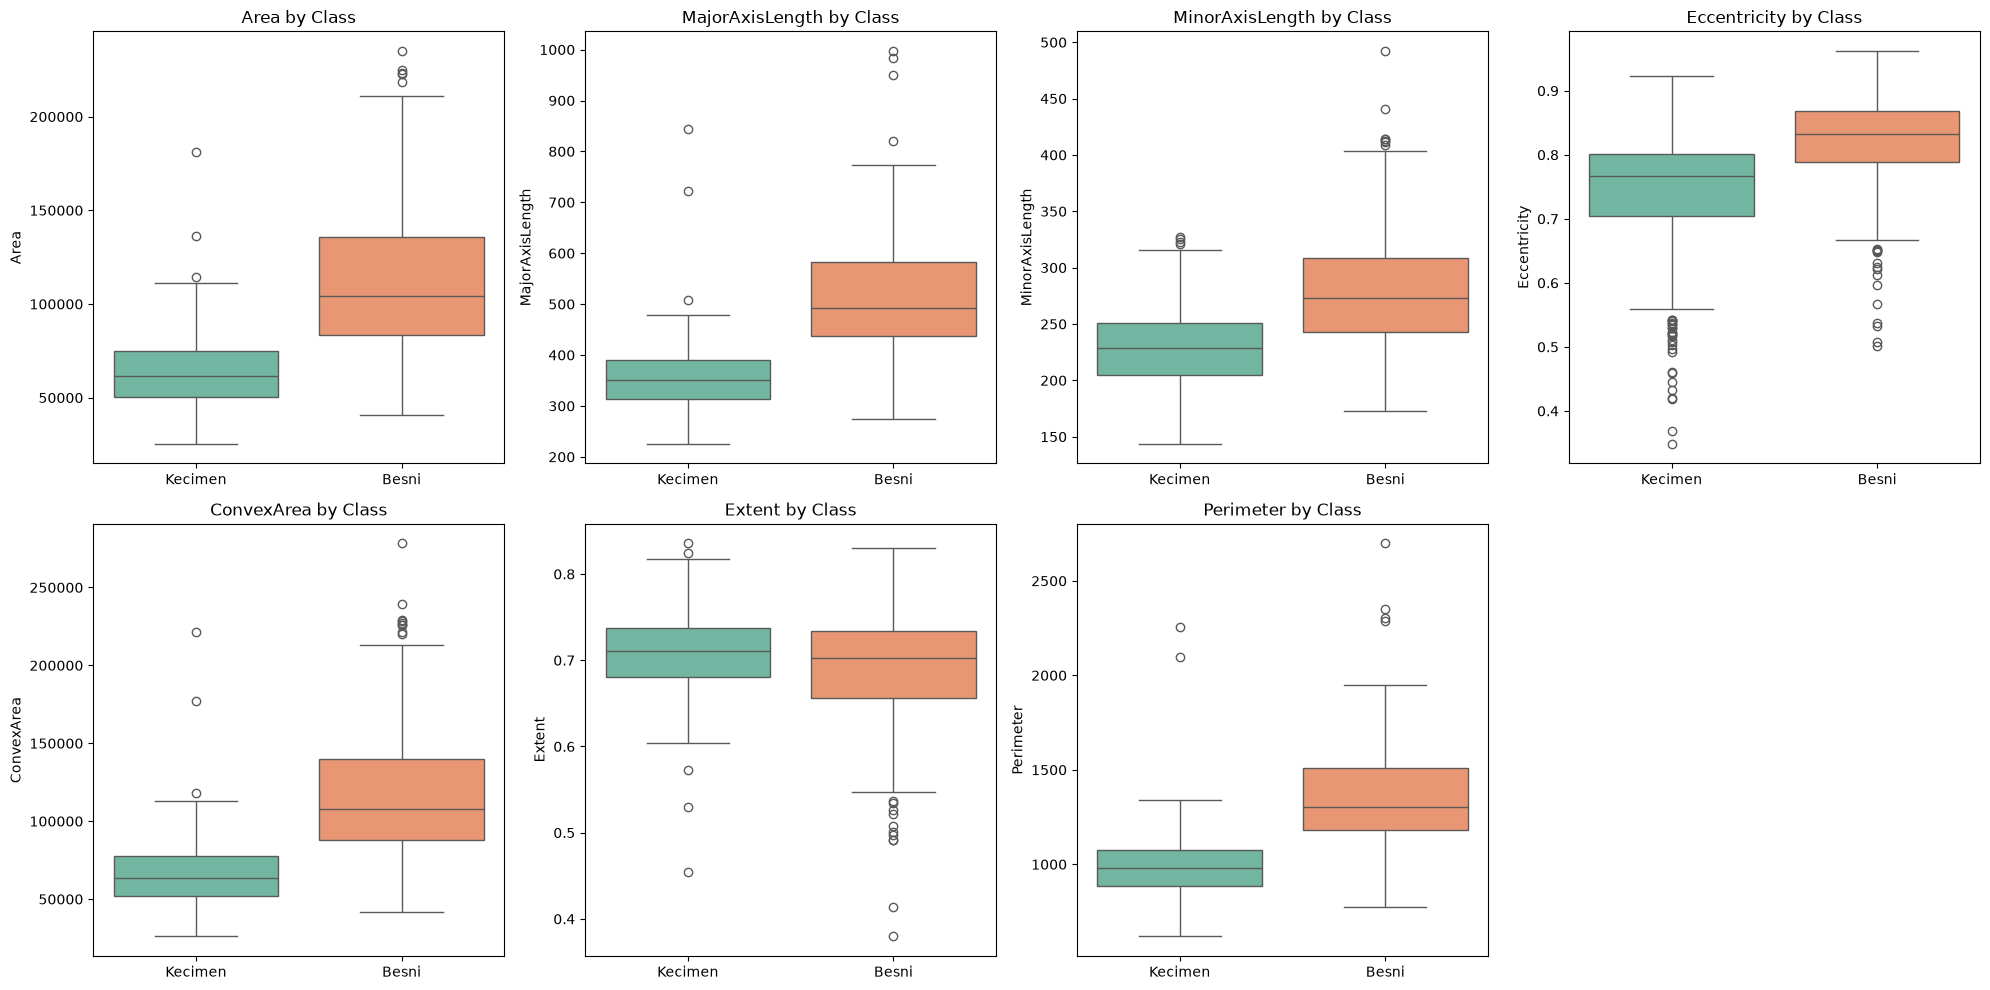

In [16]:
from ucimlrepo import fetch_ucirepo

# 1. 데이터셋 원본 그대로 로드
raisin = fetch_ucirepo(id=850)
raisin_df = raisin.data.original

# 2. 분석할 피처 리스트와 타겟 컬럼명 지정
raisin_features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
target_column = 'Class'

# 3. 보완된 함수 실행
raisin_report = analyze_features_for_selection(
    df=raisin_df, 
    feature_cols=raisin_features, 
    target_col=target_column
)

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

def analyze_features_improved(df, feature_cols, target_col, is_classification=True):
    """
    개선된 피처 분석 함수:
    - 수치형 피처 중심의 VIF 및 Mutual Information(상호 정보량) 기반 통합 분석 리포트 제공
    """
    df_analyzed = df.copy()
    
    # 1. 타겟 변수 안전 인코딩
    if is_classification and (df_analyzed[target_col].dtype in ['object', 'string', 'category']):
        le = LabelEncoder()
        df_analyzed[target_col] = le.fit_transform(df_analyzed[target_col].astype(str))
    
    # 2. 수치형 피처만 구분하여 추출 (VIF 및 상관분석용)
    numeric_features = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_analyzed[col])]
    
    if len(numeric_features) < len(feature_cols):
        ignored = set(feature_cols) - set(numeric_features)
        print(f"[주의] 수치형이 아닌 피처 {list(ignored)}는 VIF/상관관계 분석에서 제외되었습니다.")

    X_num = df_analyzed[numeric_features].copy()
    X_num = X_num.fillna(X_num.median()) # EDA용 결측치 임시 처리
    y = df_analyzed[target_col].fillna(df_analyzed[target_col].mode()[0])

    # 3. Mutual Information (비선형 포함 전체적인 의존도 측정)
    if is_classification:
        mi_scores = mutual_info_classif(X_num, y, random_state=42)
    else:
        mi_scores = mutual_info_regression(X_num, y, random_state=42)
    
    # 4. VIF 계산 (상수항 추가)
    X_vif = X_num.copy()
    X_vif['intercept'] = 1.0
    
    vif_list = []
    for i in range(X_num.shape[1]):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
            vif_list.append(vif)
        except Exception:
            vif_list.append(np.nan)

    # 5. 리포트 생성
    report_df = pd.DataFrame({
        'Feature': numeric_features,
        'Mutual_Info': mi_scores,
        'Pearson_Corr_Abs': X_num.corrwith(y).abs().values,
        'VIF_Score': vif_list
    }).sort_values(by='Mutual_Info', ascending=False).reset_index(drop=True)

    print("\n" + "="*60)
    print("         [개선된 변수 분석 통합 리포트]         ")
    print("="*60)
    print(report_df.round(4))
    print("="*60)
    print("* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심하세요.\n")

    return report_df

In [101]:
from ucimlrepo import fetch_ucirepo

# 1. 데이터셋 원본 그대로 로드
raisin = fetch_ucirepo(id=850)
raisin_df = raisin.data.original

# 2. 분석할 피처 리스트와 타겟 컬럼명 지정
raisin_features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
target_column = 'Class'

# 3. 보완된 함수 실행
raisin_report = analyze_features_improved(
    df=raisin_df, 
    feature_cols=raisin_features, 
    target_col=target_column
)



         [개선된 변수 분석 통합 리포트]         
           Feature  Mutual_Info  Pearson_Corr_Abs  VIF_Score
0        Perimeter       0.3585            0.6660   184.2528
1  MajorAxisLength       0.3483            0.6732   129.1529
2       ConvexArea       0.2975            0.6256   445.9476
3             Area       0.2776            0.6257   404.7188
4  MinorAxisLength       0.1349            0.5031    40.1666
5     Eccentricity       0.1291            0.4385     5.2104
6           Extent       0.0293            0.1547     1.6053
* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심하세요.



In [89]:
df

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen
...,...,...,...,...,...,...,...,...
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni


## 문제 1 — 측정값 2개 고르기

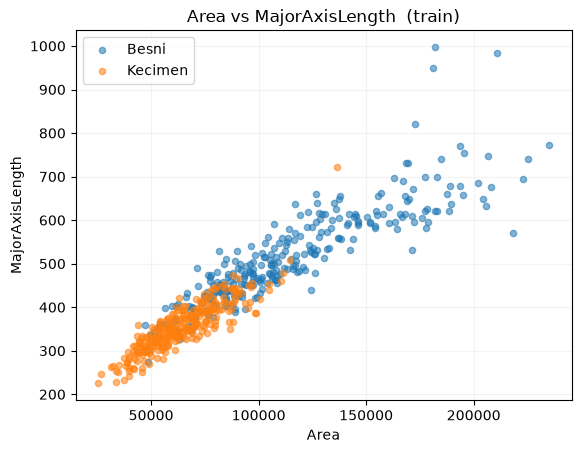

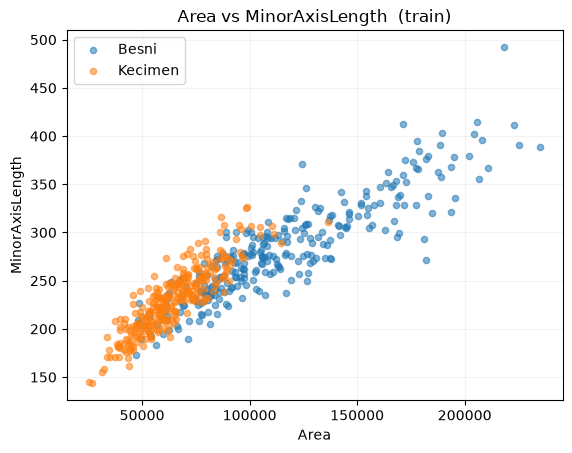

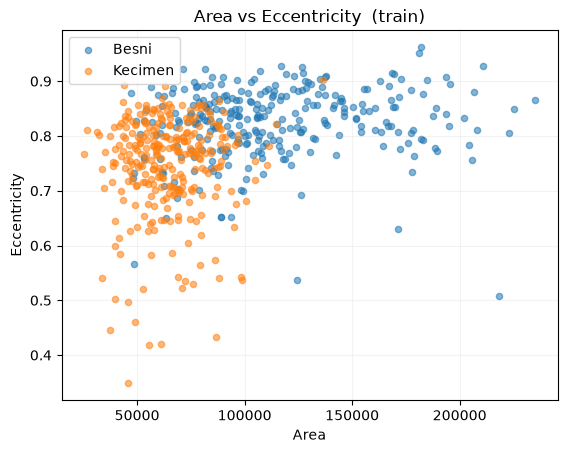

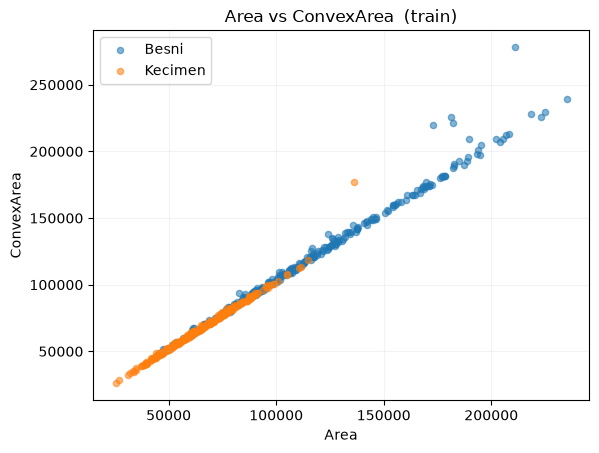

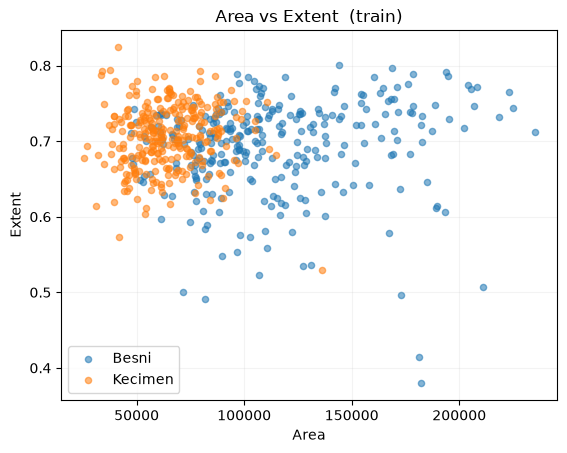

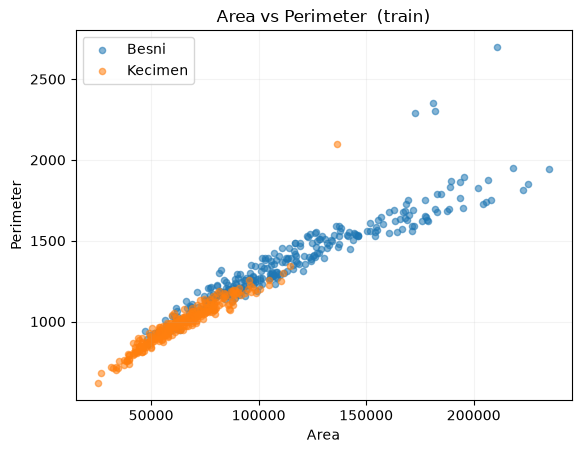

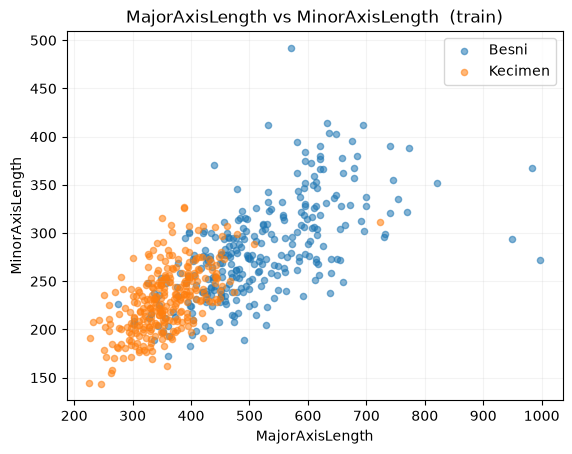

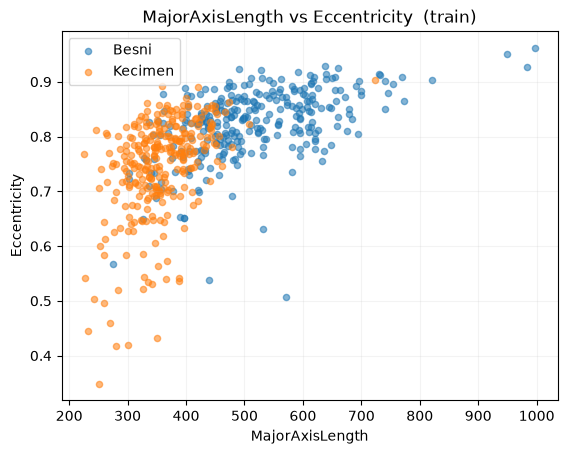

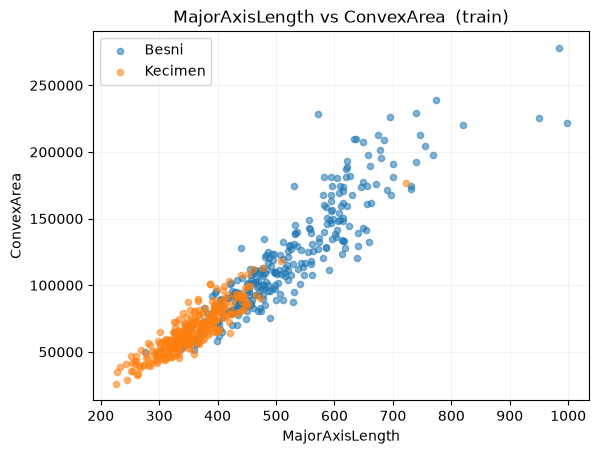

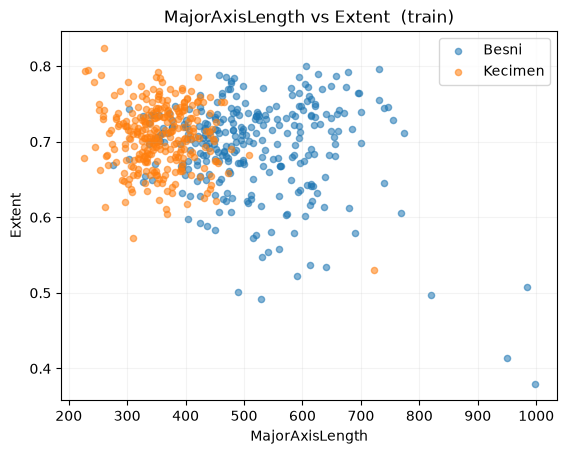

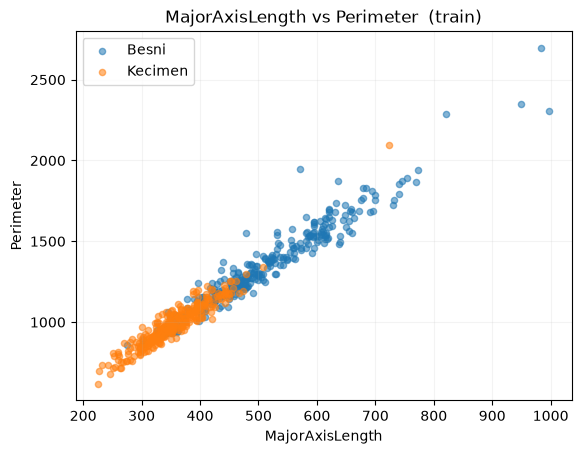

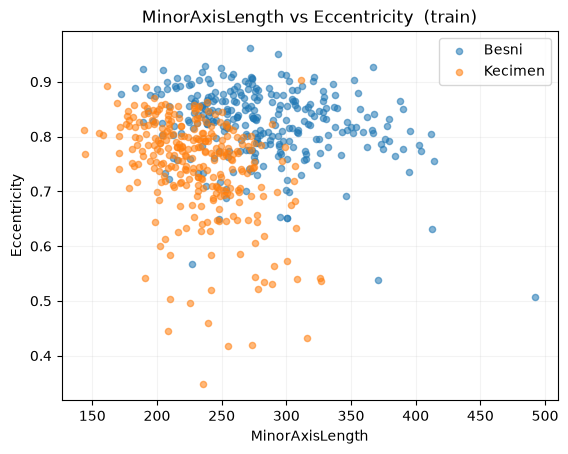

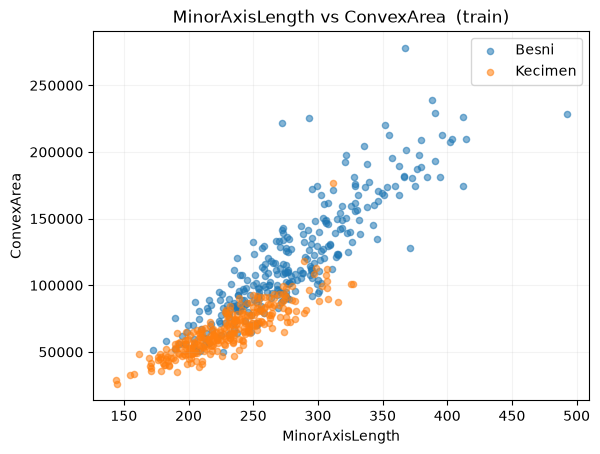

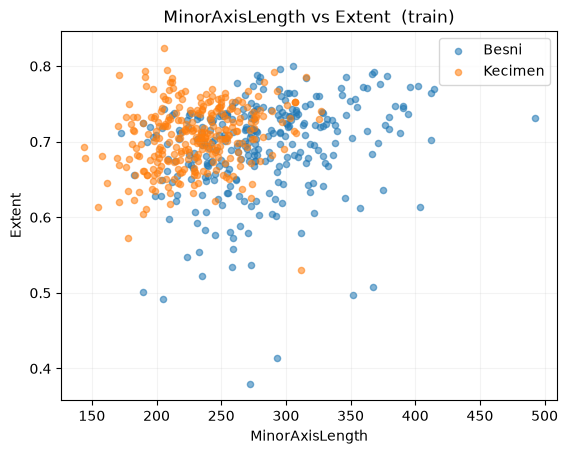

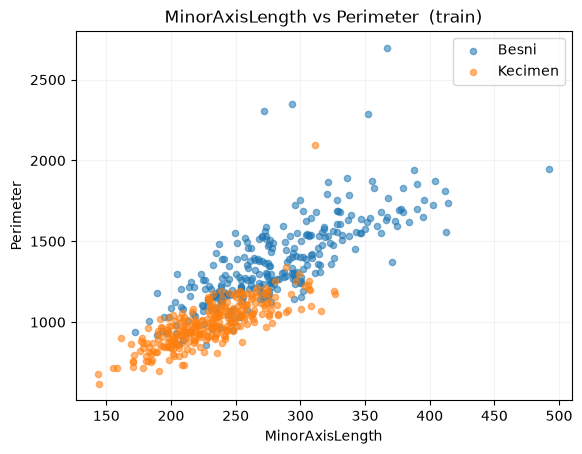

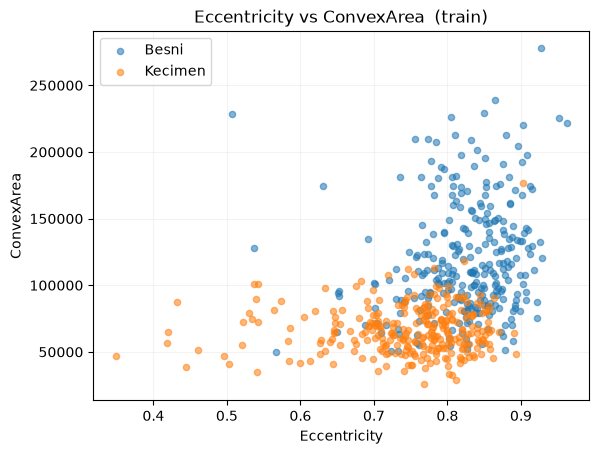

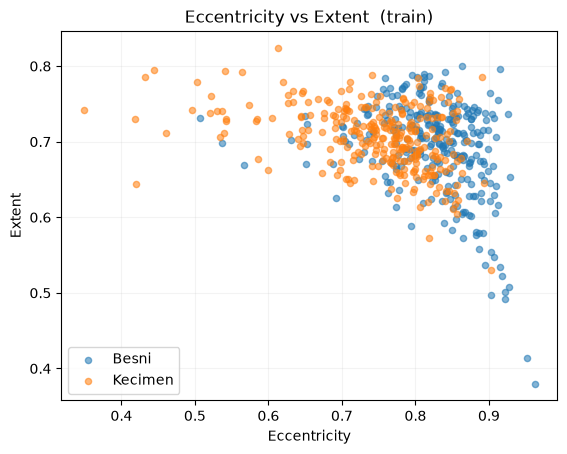

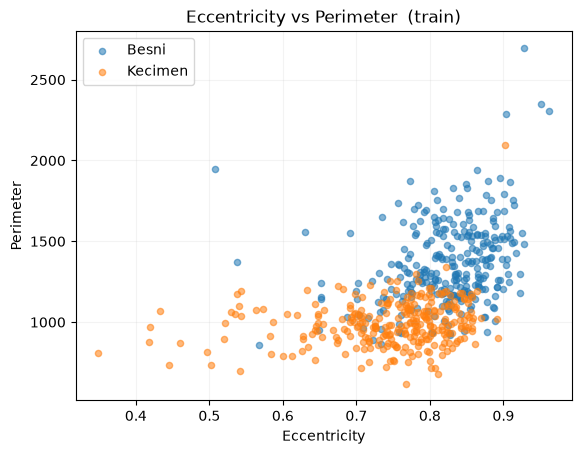

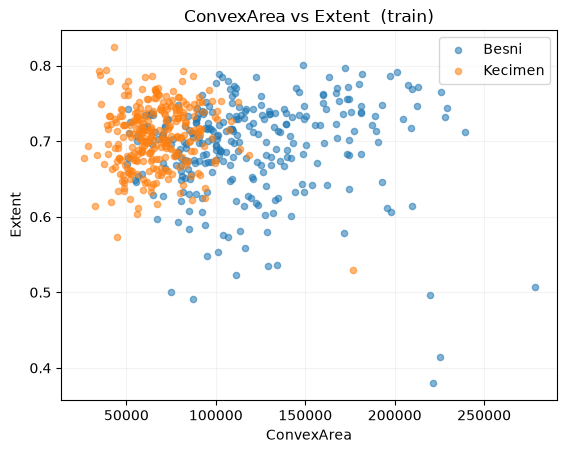

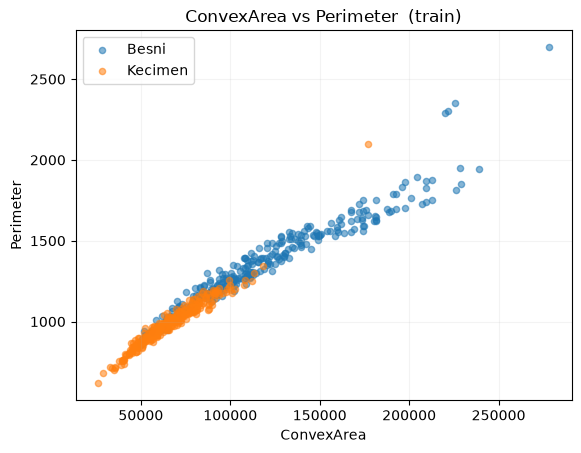

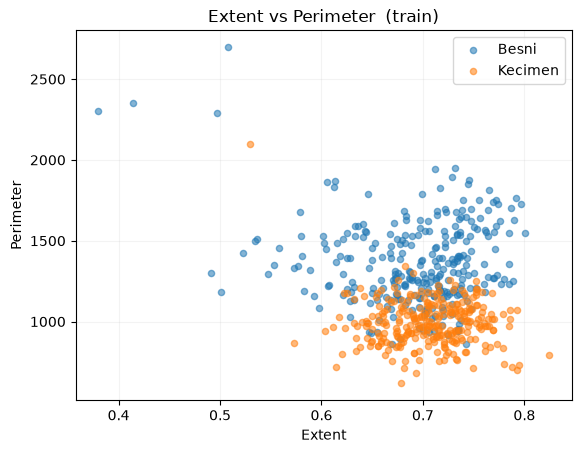

Class_encoded      1.000000
MajorAxisLength    0.673701
Perimeter          0.663787
Area               0.631170
ConvexArea         0.629449
MinorAxisLength    0.508153
Eccentricity       0.445807
Extent             0.128622
Name: Class_encoded, dtype: float64

선택된 측정값 2개: ['Area' 'MajorAxisLength' 'Perimeter']


In [ ]:
# 문제 1. 측정값 7개 중 두 개를 고르셈.
#
#   - plot_pair("Perimeter", "Eccentricity") 처럼 여러 조합을 그려보고 정하셈
#   - train 만 그려짐. validation 과 test 는 아직 보면 안 됨
#   - 고른 두 개로 입력을 만들어두면 뒤 문제에서 계속 씀
#   - 그 조합이 어느 정도인지 train 내부 CV 로 재보면 참고가 됨
#
# 아래에 작성

###########################################################################################################
##--1 눈으로 보기
###########################################################################################################

plot_pair("Area", "MajorAxisLength") 
plot_pair("Area", "MinorAxisLength") 
plot_pair("Area", "Eccentricity") 
plot_pair("Area", "ConvexArea") 
plot_pair("Area", "Extent") 
plot_pair("Area", "Perimeter") 

#plot_pair("MajorAxisLength", "MajorAxisLength") 
plot_pair("MajorAxisLength", "MinorAxisLength") 
plot_pair("MajorAxisLength", "Eccentricity") 
plot_pair("MajorAxisLength", "ConvexArea") 
plot_pair("MajorAxisLength", "Extent") 
plot_pair("MajorAxisLength", "Perimeter") 

#plot_pair("MinorAxisLength", "MajorAxisLength") 
#plot_pair("MinorAxisLength", "MinorAxisLength") 
plot_pair("MinorAxisLength", "Eccentricity") 
plot_pair("MinorAxisLength", "ConvexArea") 
plot_pair("MinorAxisLength", "Extent") 
plot_pair("MinorAxisLength", "Perimeter") 

# plot_pair("Eccentricity", "MajorAxisLength") 
# plot_pair("Eccentricity", "MinorAxisLength") 
# plot_pair("Eccentricity", "Eccentricity") 
plot_pair("Eccentricity", "ConvexArea") 
plot_pair("Eccentricity", "Extent") 
plot_pair("Eccentricity", "Perimeter") 

# plot_pair("ConvexArea", "MajorAxisLength") 
# plot_pair("ConvexArea", "MinorAxisLength") 
# plot_pair("ConvexArea", "Eccentricity") 
# plot_pair("ConvexArea", "ConvexArea") 
plot_pair("ConvexArea", "Extent") 
plot_pair("ConvexArea", "Perimeter") 

plot_pair("Extent", "Perimeter") 

###########################################################################################################
##--2 내 컬럼들 간의 상관계수(Correlation Coefficient)
###########################################################################################################
# 1. 원본 데이터 복사
df_numeric = train_df.copy()

# 2. Class 문자열을 0과 1 숫자로 맵핑하여 새로운 컬럼 추가
df_numeric["Class_encoded"] = df_numeric["Class"].map({"Besni": 0, "Kecimen": 1})

# 3. 데이터프레임 내의 모든 컬럼 타입을 명시적으로 숫자로 변환 (텍스트인 기존 Class 컬럼은 제외)
# FEATURES 변수에 들어있는 특성 이름들만 숫자로 변환합니다.
df_numeric[FEATURES] = df_numeric[FEATURES].apply(pd.to_numeric)
df_numeric["Class_encoded"] = pd.to_numeric(df_numeric["Class_encoded"])

# 4. 연산에 사용할 숫자형 컬럼들만 명시적으로 지정하여 추출
numeric_cols = FEATURES + ["Class_encoded"]

# 5. 상관계수 계산 후 절대값이 큰 순서대로 정렬
#-.corr()은 파이썬 Pandas 라이브러리에서 데이터프레임 내 컬럼들 간의 상관계수(Correlation Coefficient)를 구하는 함수입니다.
correlations = df_numeric[numeric_cols].corr()["Class_encoded"].abs().sort_values(ascending=False)

# 6. 결과 출력
display(correlations)

###########################################################################################################
##--3 Scikit-learn의 SelectKBest 활용
###########################################################################################################

from sklearn.feature_selection import SelectKBest, f_classif

# 1. feature와 target 분리
X_train = train_df[FEATURES]
y = train_df["Class"]

# 2. 가장 성능이 좋은 특징 2개 선택기 생성 및 학습
selector = SelectKBest(score_func=f_classif, k=2)
selector.fit(X_train, y)

# 3. 선택된 특징 이름 출력
selected_features = np.array(FEATURES)[selector.get_support()]
print("선택된 측정값 2개:", selected_features)







<details><summary>💡 힌트</summary>

두 품종의 점이 **덜 겹치는** 조합을 찾으면 됨.
겹치는 구간이 넓으면 어떤 모델을 써도 그 구간은 못 가름.

```python
X_train = train_df[["Perimeter", "Eccentricity"]]
X_valid = valid_df[["Perimeter", "Eccentricity"]]
```

train 내부 CV 로 참고값을 보고 싶으면 `cross_val_score(모델, X_train, y_train, cv=5).mean()`.

</details>

**서술 1.** 이 두 개를 고른 이유를 적으셈. 산점도에서 무엇을 봤는지 쓰셈.

```
답:
```

In [7]:
X_train

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
475,177264,619.958472,366.763240,0.806237,180994,0.683219,1652.694
39,49882,287.264327,222.185873,0.633852,50880,0.766378,843.764
192,37569,232.427848,208.152006,0.444950,38874,0.794371,734.102
585,61444,371.693826,213.179806,0.819180,64321,0.737473,1006.984
535,77012,425.219427,239.469561,0.826343,81325,0.654280,1131.530
...,...,...,...,...,...,...,...
298,105020,440.389631,306.105289,0.718934,107423,0.714616,1228.366
517,97375,468.904038,268.267025,0.820173,100169,0.694717,1244.252
834,145235,609.630181,306.608036,0.864321,148876,0.682495,1538.316
456,134303,600.766271,288.384930,0.877253,138133,0.742436,1497.515


In [5]:
###########################################################################################################
##--3 Scikit-learn의 SelectKBest 활용
###########################################################################################################

from sklearn.feature_selection import SelectKBest, f_classif

# 1. feature와 target 분리
X_train = train_df[FEATURES]
y = train_df["Class"]

# 2. 가장 성능이 좋은 특징 2개 선택기 생성 및 학습
selector = SelectKBest(score_func=f_classif, k=2)
selector.fit(X_train, y)

# 3. 선택된 특징 이름 출력
selected_features = np.array(FEATURES)[selector.get_support()]
print("선택된 측정값 2개:", selected_features)


선택된 측정값 2개: ['MajorAxisLength' 'Perimeter']


In [75]:
###########################################################################################################
##--2 내 컬럼들 간의 상관계수(Correlation Coefficient)
###########################################################################################################
# 1. 원본 데이터 복사
df_numeric = train_df.copy()

# 2. Class 문자열을 0과 1 숫자로 맵핑하여 새로운 컬럼 추가
df_numeric["Class_encoded"] = df_numeric["Class"].map({"Besni": 0, "Kecimen": 1})

# 3. 데이터프레임 내의 모든 컬럼 타입을 명시적으로 숫자로 변환 (텍스트인 기존 Class 컬럼은 제외)
# FEATURES 변수에 들어있는 특성 이름들만 숫자로 변환합니다.
df_numeric[FEATURES] = df_numeric[FEATURES].apply(pd.to_numeric)
df_numeric["Class_encoded"] = pd.to_numeric(df_numeric["Class_encoded"])

# 4. 연산에 사용할 숫자형 컬럼들만 명시적으로 지정하여 추출
numeric_cols = FEATURES + ["Class_encoded"]

# 5. 상관계수 계산 후 절대값이 큰 순서대로 정렬
#-.corr()은 파이썬 Pandas 라이브러리에서 데이터프레임 내 컬럼들 간의 상관계수(Correlation Coefficient)를 구하는 함수입니다.
correlations = df_numeric[numeric_cols].corr()["Class_encoded"].abs().sort_values(ascending=False)

# 6. 결과 출력
display(correlations)

Class_encoded      1.000000
MajorAxisLength    0.673701
Perimeter          0.663787
Area               0.631170
ConvexArea         0.629449
MinorAxisLength    0.508153
Eccentricity       0.445807
Extent             0.128622
Name: Class_encoded, dtype: float64

In [79]:
y_train

475      Besni
39     Kecimen
192    Kecimen
585      Besni
535      Besni
        ...   
298    Kecimen
517      Besni
834      Besni
456      Besni
671      Besni
Name: Class, Length: 576, dtype: str

In [77]:
train_df

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
475,177264,619.958472,366.763240,0.806237,180994,0.683219,1652.694,Besni
39,49882,287.264327,222.185873,0.633852,50880,0.766378,843.764,Kecimen
192,37569,232.427848,208.152006,0.444950,38874,0.794371,734.102,Kecimen
585,61444,371.693826,213.179806,0.819180,64321,0.737473,1006.984,Besni
535,77012,425.219427,239.469561,0.826343,81325,0.654280,1131.530,Besni
...,...,...,...,...,...,...,...,...
298,105020,440.389631,306.105289,0.718934,107423,0.714616,1228.366,Kecimen
517,97375,468.904038,268.267025,0.820173,100169,0.694717,1244.252,Besni
834,145235,609.630181,306.608036,0.864321,148876,0.682495,1538.316,Besni
456,134303,600.766271,288.384930,0.877253,138133,0.742436,1497.515,Besni


## 문제 2 — 로지스틱 회귀 vs KNN

In [21]:
## e정답
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

F1, F2 = "Perimeter", "Eccentricity"
X_train, X_valid = train_df[[F1, F2]], valid_df[[F1, F2]]

lr = LogisticRegression(max_iter=5000).fit(X_train, y_train)
lr_pred = lr.predict(X_valid)
lr_acc = accuracy_score(y_valid, lr_pred)
lr_prec = precision_score(y_valid, lr_pred, average='macro')
lr_recall  = recall_score(y_valid, lr_pred, average='macro')

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
knn_pred = knn.predict(X_valid)
knn_acc = accuracy_score(y_valid, knn_pred)
knn_prec = precision_score(y_valid, knn_pred, average='macro')
knn_recall  = recall_score(y_valid, knn_pred, average='macro')

print(f"lr_acc         {lr_acc:.4f}   (기준선 대비 {lr_acc-0.5:+.4f})")
print(f"lr_prec        {lr_prec:.4f}   (기준선 대비 {lr_prec-0.5:+.4f})")
print(f"lr_recall      {lr_recall:.4f}   (기준선 대비 {lr_recall-0.5:+.4f})")
print(f"knn_acc k=5    {knn_acc:.4f}   (기준선 대비 {knn_acc-0.5:+.4f})")
print(f"knn_prec       {knn_prec:.4f}   (기준선 대비 {knn_prec-0.5:+.4f})")
print(f"knn_recall     {knn_recall:.4f}   (기준선 대비 {knn_recall-0.5:+.4f})")

lr_acc         0.8750   (기준선 대비 +0.3750)
lr_prec        0.8776   (기준선 대비 +0.3776)
lr_recall      0.8750   (기준선 대비 +0.3750)
knn_acc k=5    0.8611   (기준선 대비 +0.3611)
knn_prec       0.8622   (기준선 대비 +0.3622)
knn_recall     0.8611   (기준선 대비 +0.3611)


In [4]:
# 문제 2. 고른 2개로 두 모델을 만들고 validation 정확도를 비교하셈.
#
#   - 로지스틱 회귀 : LogisticRegression(max_iter=5000)
#   - KNN          : KNeighborsClassifier(n_neighbors=5)   ← 아직 스케일링 안 함
#   - 두 점수를 기준선 0.5 와도 비교해보셈
#   - 뒤에서 예측 결과를 다시 쓰니까 predict 결과도 남겨두셈
#
# 아래에 작성

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 앞서 고른 측정값 2개만 추출해 테스트
#selected_features = ['MajorAxisLength', 'Perimeter']
#selected_features = ['MajorAxisLength', 'Perimeter','Area','ConvexArea']
#selected_features = ['MajorAxisLength', 'Perimeter','Area','ConvexArea','MinorAxisLength']
selected_features = ['Perimeter', 'Eccentricity']

X_t = train_df[selected_features]
X_v = valid_df[selected_features]

# 1. 정답 데이터(y)를 문자열에서 0과 1로 변환
y_train_encoded = y_train.map({"Kecimen": 0, "Besni": 1})


# 파이프라인
pipe =Pipeline(
    [
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression())
    ]
)

# 비교 CV 스페이스 정의
param_grid = [
    {
        'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
        'classifier': [LogisticRegression(random_state=42)],
        'classifier__C' : [0.001, 0.01, 0.1, 1.0, 10.0, 100.0] ,
        'classifier__max_iter' : [50,100,500,1000,1500,2500,5000]
    },
    {
        'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
        'classifier' : [KNeighborsClassifier()],
        'classifier__n_neighbors' : [3, 5, 7, 9, 11, 13, 15] ,
        'classifier__weights' : ['uniform', 'distance'] 
    }
]
# 4. GridSearchCV 실행 (여기서는 Validation 세트의 역할을 대신함)
# train과 valid를 합친 데이터로 교차검증(CV)을 하거나, train으로만 검증 가능
grid = GridSearchCV(pipe, param_grid, cv=5, 
                    scoring=['accuracy', 'precision', 'recall', 'f1'], # 4가지 기준으로 모두 채점!
                    refit='f1' # 최종 1등 모델을 결정하는 결정타는 'f1-score'로 하겠다는 의미
                    )
#grid.fit(X_t, y_train)
grid.fit(X_t, y_train_encoded)



# 5. 최적의 모델 결과 확인
print("\n1. 최적의 모델 종류:")
print(grid.best_estimator_) 

print("\n2. 최적의 하이퍼파라미터:")
print(grid.best_params_)

print("\n3. 최적 모델의 교차검증(CV) 정확도:")
print(f"{grid.best_score_:.4f}")

# 1. GridSearchCV 학습 완료 후 실행 (grid.fit 이후)
results_df = pd.DataFrame(grid.cv_results_)
# 2. 파라미터 조합, 평균값, 표준편차, 등수 컬럼만 선택
print(results_df.columns.tolist())
#columns_to_show = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']

# 3. 등수(Rank) 순으로 정렬하여 출력
#display(results_df[columns_to_show].sort_values(by='rank_test_score'))
#display(results_df[columns_to_show].sort_values(by=columns_to_show[-1]))



# # 1등인 행의 mean_test_score 가져오기
# rank_1_mean_score = grid.cv_results_['mean_test_score'][grid.best_index_]
# # grid.best_score_와 소수점 끝까지 일치하는지 비교
# print(np.isclose(grid.best_score_, rank_1_mean_score))  # 출력: True



1. 최적의 모델 종류:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=0.01, max_iter=50, random_state=42))])

2. 최적의 하이퍼파라미터:
{'classifier': LogisticRegression(random_state=42), 'classifier__C': 0.01, 'classifier__max_iter': 50, 'scaler': StandardScaler()}

3. 최적 모델의 교차검증(CV) 정확도:
0.8592
['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_classifier', 'param_classifier__C', 'param_classifier__max_iter', 'param_scaler', 'param_classifier__n_neighbors', 'param_classifier__weights', 'params', 'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy', 'split0_test_precision', 'split1_test_precision', 'split2_test_precision', 'split3_test_precision', 'split4_test_precision', 'mean_test_precision', 'std_test_precision', 'rank_test_precision', 'split0_test_recall', 'split1_test_recall

In [71]:
pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'scaler', 'classifier', 'scaler__copy', 'scaler__with_mean', 'scaler__with_std', 'classifier__C', 'classifier__class_weight', 'classifier__dual', 'classifier__fit_intercept', 'classifier__intercept_scaling', 'classifier__l1_ratio', 'classifier__max_iter', 'classifier__n_jobs', 'classifier__penalty', 'classifier__random_state', 'classifier__solver', 'classifier__tol', 'classifier__verbose', 'classifier__warm_start'])

<details><summary>💡 힌트 — 코드 형태</summary>

```python
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_valid)
print(accuracy_score(y_valid, lr_pred))
```

KNN 도 클래스 이름만 바꾸면 같은 형태임.

</details>

## 문제 3 — 스케일링하면 KNN이 달라지는가

4-2 에서 배운 것: **KNN 은 거리로 판단하므로 단위가 다르면 큰 값이 거리를 지배함.**

In [22]:
# 문제 3. 스케일링한 뒤 KNN(k=5) 을 다시 재보셈.
#
#   확인할 것 두 가지
#     1) 정확도가 어떻게 바뀌었는가
#     2) 예측이 바뀐 건포도가 몇 개인가   ← 문제 2의 예측과 비교
#
#   ⚠️ train 에는 fit_transform, validation 에는 transform. 3-1 규율임.
#      스케일링 전과 점수가 완전히 같으면 스케일링 안 한 데이터를 넣은 것임.
#
# 아래에 작성

sc = StandardScaler()
X_train_s = sc.fit_transform(X_train) # train 에서 fit_trainsform
X_valid_s = sc.transform(X_valid)     # validation 에서 transform

knn_s = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
pred_s = knn_s.predict(X_valid_s)
scaled_acc = accuracy_score(y_valid, pred_s) 
changed = int((knn_pred != pred_s).sum())


print(f"스케일링 전  {knn_acc:.4f}")
print(f"스케일링 후  {scaled_acc:.4f}")
print(f"예측이 바뀐 건포도  {changed} / {len(y_valid)}")


스케일링 전  0.8611
스케일링 후  0.8681
예측이 바뀐 건포도  19 / 144


<details><summary>💡 힌트 1 — 방향</summary>

`StandardScaler()` 를 만들고 train 에 `fit_transform`, validation 에 `transform`.
KNN 은 문제 2 와 똑같고 **넣는 데이터만** 바뀜.

바뀐 개수는 스케일링 전 예측과 후 예측을 비교하면 됨.

</details>

<details><summary>💡 힌트 2 — 코드 형태</summary>

```python
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_valid_s = sc.transform(X_valid)

knn_s = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
pred_s = knn_s.predict(X_valid_s)

print((knn_pred != pred_s).sum(), "개 바뀜")
```

</details>

**서술 2.** 스케일링 전후로 무엇이 달라졌는지 적으셈. 점수만 말고 **바뀐 개수**도 근거로 쓰셈.

```
답:
```

## 문제 4 — k 고르기

In [23]:
# 문제 4. k=5 는 그냥 쓴 값임. train 내부 CV 로 골라보셈.
#
#   - 후보 k 를 직접 정하셈 (최소 3개)
#   - Pipeline + GridSearchCV 를 쓰면 스케일링까지 같이 처리됨
#   - Pipeline 안에 scaler 가 있으면 X_train 을 그대로 넣으면 됨
#   - 고른 k 로 만든 모델의 validation 정확도도 구해두셈 (문제 5에서 씀)
#
# 아래에 작성

K_LIST = [3, 5, 7, 9, 11, 15]
pipe = Pipeline([ ("scaler", StandardScaler()), ("knn", KNeighborsClassifier()) ])
grid = GridSearchCV(pipe, {"knn__n_neighbors": K_LIST}, cv=5).fit(X_train, y_train)

best_k = grid.best_params_["knn__n_neighbors"]
tuned_acc = accuracy_score(y_valid, grid.predict(X_valid))

print(f"후보        {K_LIST}")
print(f"고른 k      {best_k}   (train CV {grid.best_score_:.4f})")
print(f"validation  {tuned_acc:.4f}   (k=5 였을 때 {scaled_acc:.4f})")





후보        [3, 5, 7, 9, 11, 15]
고른 k      15   (train CV 0.8594)
validation  0.8681   (k=5 였을 때 0.8681)


<details><summary>💡 힌트 1 — 방향</summary>

`Pipeline([("scaler", ...), ("knn", ...)])` 을 만들고
`GridSearchCV(pipe, {"knn__n_neighbors": 후보리스트}, cv=5)` 로 `X_train` 에 학습.

`grid.best_params_` 로 고른 k 를 볼 수 있음.

</details>

<details><summary>💡 힌트 2 — 코드 형태</summary>

```python
pipe = Pipeline([("scaler", StandardScaler()),
                 ("knn", KNeighborsClassifier())])
grid = GridSearchCV(pipe, {"knn__n_neighbors": [3, 5, 7, 9, 11, 15]}, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(accuracy_score(y_valid, grid.predict(X_valid)))
```

</details>

## 문제 5 — 최종 모델 하나 고르기

In [24]:
# 문제 5. 지금까지 나온 네 가지를 한 표로 모아서 보셈.
#
#     로지스틱 회귀
#     KNN k=5 (스케일링 없음)
#     KNN k=5 (스케일링)
#     KNN 고른 k (튜닝)
#
#   표를 보고 하나만 고르셈. 아래 서술 3 에 근거 2개를 적으면 됨.
#
# 아래에 작성

board = pd.DataFrame({
    "모델": ["로지스틱 회귀", "KNN k=5 raw", "KNN k=5 scaled", f"KNN k={best_k} tuned"],
    "validation": [lr_acc, knn_acc, scaled_acc, tuned_acc],
})
print(board.round(4).to_string(index=False))





            모델  validation
       로지스틱 회귀      0.8750
   KNN k=5 raw      0.8611
KNN k=5 scaled      0.8681
KNN k=15 tuned      0.8681


<details><summary>💡 힌트</summary>

`pd.DataFrame({"모델": [...], "validation": [...]})` 로 표를 만들면 보기 편함.

점수가 비슷하면 **더 단순한 쪽**을 고르는 것도 근거가 됨.
4-2 에서 본 것처럼 **동점이면 성능으로는 못 고름.**

</details>

**서술 3.** 어느 것을 고를지 정하고 **근거 2개**를 적으셈.
정확도 말고 다른 근거도 하나는 쓰셈 (예: 바뀐 예측 개수, 기준선 대비, 단순함).

```
최종 선택:
근거 1:
근거 2:
```

## 문제 6 — test 딱 한 번

> **여기까지 오기 전에 test 를 열었으면 안 됨.**

In [30]:
# 문제 6. 고른 모델을 development 720행으로 다시 학습시키고 test 를 한 번 평가하셈.
#
#   - development 는 dev 변수에 있음 (train + validation)
#   - 스케일링한 KNN 을 골랐다면 재학습 때 scaler 도 다시 fit 돼야 하므로
#     Pipeline 을 쓰는 게 안전함
#   - test 는 180개임. 한 명 틀리면 정확도가 얼마나 움직이는지도 계산해보셈
#
#   ⚠️ 결과를 보고 모델을 바꾸지 마셈.
#
# 아래에 작성

X_dev, X_test = dev[[F1, F2]], test_df[[F1, F2]]
final_model = LogisticRegression(max_iter=5000)
final_model.fit(X_dev, dev["Class"])
#model_predict = final_model.predict(X_test)
test_acc = accuracy_score(y_test, final_model.predict(X_test))

print(f"validation  {lr_acc:.4f}")
print(f"final test  {test_acc:.4f}   (n={len(y_test)})")
print(f"1명 틀릴 때 움직이는 폭  {1/len(y_test):.4f}")





validation  0.8750
final test  0.8611   (n=180)
1명 틀릴 때 움직이는 폭  0.0056


<details><summary>💡 힌트 — 코드 형태</summary>

```python
X_dev  = dev[["Perimeter", "Eccentricity"]]
X_test = test_df[["Perimeter", "Eccentricity"]]
y_dev  = dev["Class"]

final_model.fit(X_dev, y_dev)
print(accuracy_score(y_test, final_model.predict(X_test)))
```

</details>

---

**서술 4.** validation 점수와 test 점수를 비교해서 적으셈.

```
validation:
test:
차이:
왜 이런 차이가 났다고 생각하는가:
```

**서술 5.** 이 모델의 한계를 하나 적으셈.

```
답:
```

**서술 6.** 시간이 더 있다면 다음에 무엇을 확인하고 싶은가.

```
답:
```

---

### 제출 전 확인

- [ ] 문제 6 전에 test 를 열지 않았음
- [ ] test 결과를 보고 모델을 바꾸지 않았음
- [ ] 서술 6개를 채웠음
- [ ] **Restart & Run All** 로 끝까지 도는지 확인했음

수업 시간에 각자 화면을 보면서 같이 이야기할 거임. **답이 서로 다른 게 정상임.**